# 03 — Extended Kalman Filter Localization

**Section:** Localization · **Mirrors MATLAB:** *Monte Carlo Localization* (similar problem, EKF approach)

We track the pose `[x, y, θ]` of a unicycle robot moving in a circle, using **range + bearing** measurements to known landmarks. The EKF linearizes the nonlinear motion and observation models around the current estimate at each step.


## Motion and observation models

**Motion:**
$x_{t+1} = x_t + \Delta t \cdot v \cos\theta_t$
$y_{t+1} = y_t + \Delta t \cdot v \sin\theta_t$
$\theta_{t+1} = \theta_t + \Delta t \cdot \omega$

**Observation** of landmark $\ell$:
$z = [r,\ \phi]^T = [\|\ell - p\|,\ \arctan2(\ell_y - y, \ell_x - x) - \theta]^T$

The EKF linearizes both with the Jacobians $G_x$ and $H$ at each step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T = 200
dt = 0.1
v, omega = 1.0, 0.1

# Ground-truth trajectory (circle)
true_x = np.zeros((T, 3))
for t in range(1, T):
    th = true_x[t - 1, 2]
    true_x[t] = true_x[t - 1] + dt * np.array([v * np.cos(th), v * np.sin(th), omega])

landmarks = np.array([[5, 5], [-5, 5], [-5, -5], [5, -5], [0, 10], [10, 0]])


In [2]:
Q = np.diag([0.05, 0.05, 0.01]) ** 2      # process noise
R = np.diag([0.2, 0.05]) ** 2             # measurement noise (range, bearing)


def motion(x, u, dt):
    return x + dt * np.array([u[0] * np.cos(x[2]), u[0] * np.sin(x[2]), u[1]])


def G_x(x, u, dt):
    return np.array([[1, 0, -u[0] * np.sin(x[2]) * dt],
                     [0, 1,  u[0] * np.cos(x[2]) * dt],
                     [0, 0, 1]])


def observe(x, lm):
    dx, dy = lm[0] - x[0], lm[1] - x[1]
    return np.array([np.hypot(dx, dy), np.arctan2(dy, dx) - x[2]])


def H_jacobian(x, lm):
    dx, dy = lm[0] - x[0], lm[1] - x[1]
    q = dx * dx + dy * dy
    r = np.sqrt(q)
    return np.array([[-dx / r, -dy / r, 0],
                     [ dy / q, -dx / q, -1]])


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


In [3]:
mu = np.array([0.0, 0.0, 0.0])
Sigma = np.eye(3) * 0.1
mu_hist = [mu.copy()]

for t in range(1, T):
    u_noisy = [v + np.random.randn() * 0.05, omega + np.random.randn() * 0.01]
    mu = motion(mu, u_noisy, dt)
    G = G_x(mu, u_noisy, dt)
    Sigma = G @ Sigma @ G.T + Q

    for lm in landmarks:
        z = observe(true_x[t], lm) + np.random.multivariate_normal([0, 0], R)
        z_hat = observe(mu, lm)
        innov = z - z_hat
        innov[1] = wrap(innov[1])
        H = H_jacobian(mu, lm)
        S = H @ Sigma @ H.T + R
        K = Sigma @ H.T @ np.linalg.inv(S)
        mu = mu + K @ innov
        Sigma = (np.eye(3) - K @ H) @ Sigma

    mu_hist.append(mu.copy())

mu_hist = np.array(mu_hist)
err = np.linalg.norm(mu_hist[:, :2] - true_x[:, :2], axis=1)
print(f"Mean position error: {err.mean():.3f} m  ·  max: {err.max():.3f} m")


Mean position error: 0.063 m  ·  max: 0.209 m


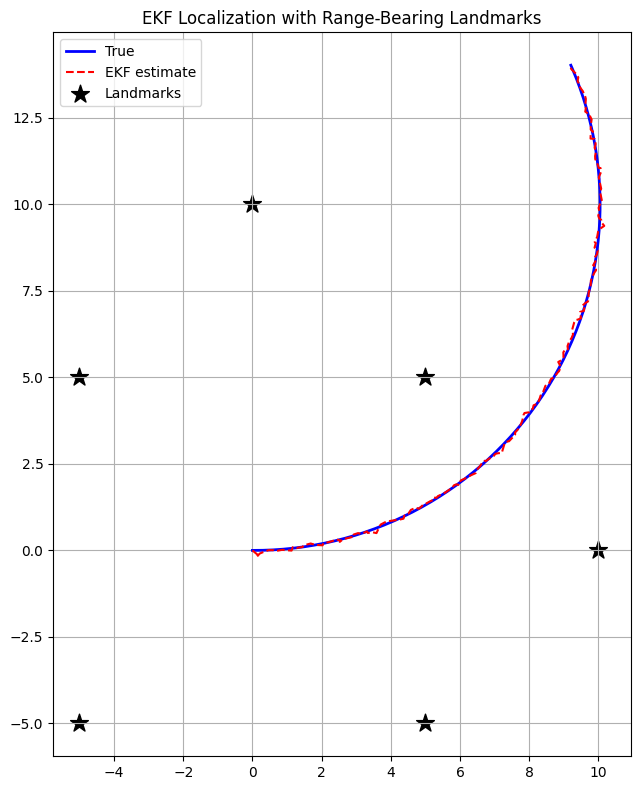

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(true_x[:, 0], true_x[:, 1], 'b-', lw=2, label='True')
ax.plot(mu_hist[:, 0], mu_hist[:, 1], 'r--', lw=1.5, label='EKF estimate')
ax.scatter(landmarks[:, 0], landmarks[:, 1], c='k', marker='*', s=180, label='Landmarks')
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_title('EKF Localization with Range-Bearing Landmarks')
plt.tight_layout()
plt.show()
